In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

## STEP 1: Basic Exploration

In [4]:

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  


# STEP 2: Missing Values

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())



Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Missing values after handling:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


# STEP 3: Remove Duplicates

In [6]:
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after duplicate removal:", df.shape)


Duplicate Rows: 0
Shape after duplicate removal: (1200, 14)


# STEP 4: Outlier Detection & Removal using IQR

In [7]:
numerical_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nShape after outlier removal:", df.shape)


Shape after outlier removal: (1192, 14)


# STEP 5: Feature Engineering

In [8]:
# Feature 1: Order Year
df['OrderYear'] = pd.to_datetime(df['Date']).dt.year

# Feature 2: Order Month
df['OrderMonth'] = pd.to_datetime(df['Date']).dt.month

# Feature 3: Price Per Cart Item
df['PricePerCartItem'] = df['TotalPrice'] / df['ItemsInCart']

# Feature 4: Discount Applied
df['DiscountApplied'] = df['CouponCode'].apply(lambda x: 1 if pd.notnull(x) else 0)

print("\nNew Features Added:")
print(df[['OrderYear', 'OrderMonth', 'PricePerCartItem', 'DiscountApplied']].head())


New Features Added:
   OrderYear  OrderMonth  PricePerCartItem  DiscountApplied
0       2023           1        407.585714                1
1       2024           8        100.900000                1
2       2024           2        344.175000                1
3       2023          10         54.638000                1
4       2025           5        313.005000                1


# STEP 6: Data Visualization

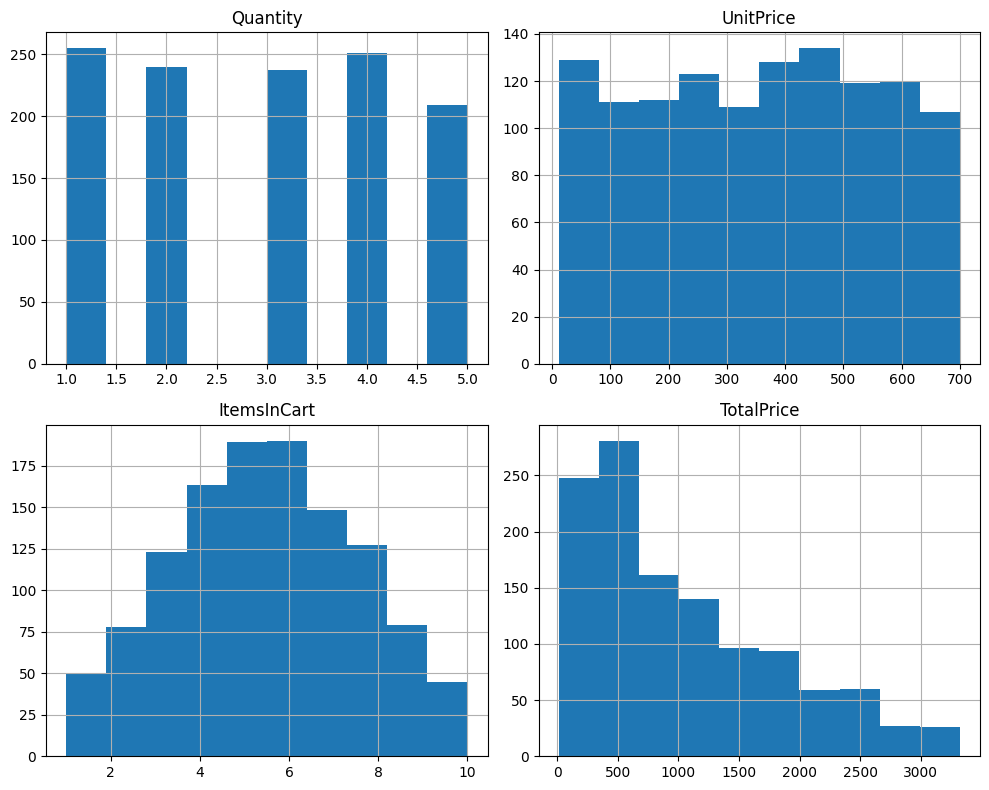

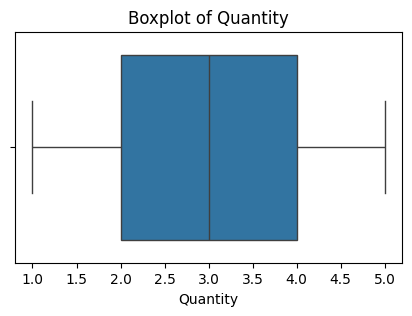

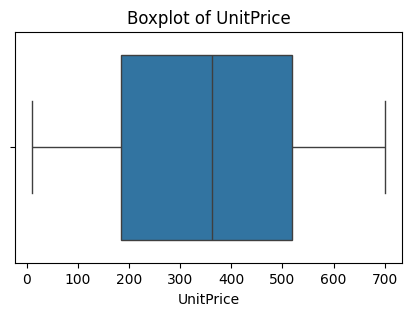

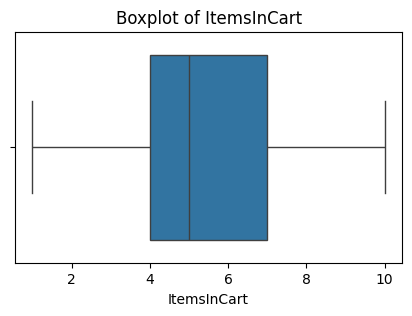

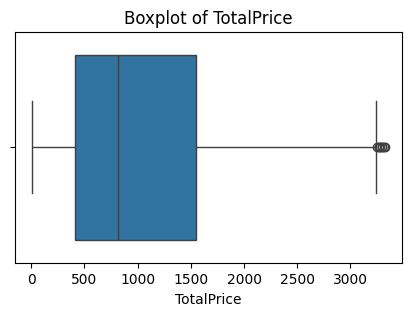

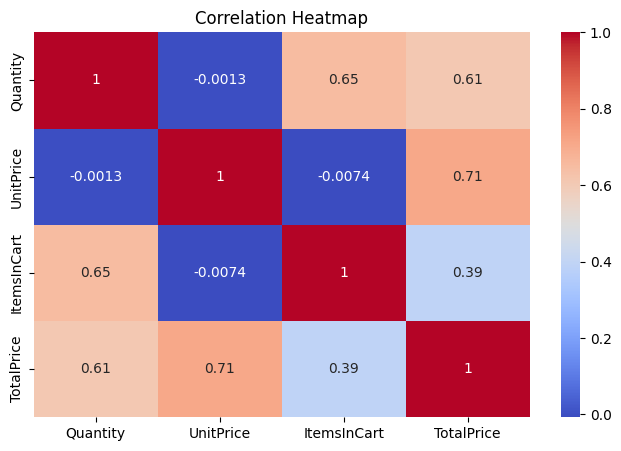

In [9]:
# Histogram
df[numerical_columns].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# Boxplots
for col in numerical_columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()